In [2]:
# Import các thư viện cần thiết cho PyTorch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scikit-learn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Thiết lập font chữ cho biểu đồ
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'DejaVu Sans'

# Kiểm tra GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Đang sử dụng thiết bị: {device}")
print("✅ Đã import tất cả thư viện thành công!")

✅ Đang sử dụng thiết bị: cuda
✅ Đã import tất cả thư viện thành công!


In [6]:
# Đọc file vừa upload (tên file là Churn_Modelling.csv)
df = pd.read_csv('Churn_Modelling.csv')

print("📊 Kích thước dataset:", df.shape)
print("\n🔍 5 dòng dữ liệu đầu tiên:")
df.head()

📊 Kích thước dataset: (10000, 14)

🔍 5 dòng dữ liệu đầu tiên:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


📋 Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

❓ Số lượng giá trị null trong từng cột:
RowNumber          0
CustomerId 

/tmp/ipykernel_642/1693388344.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='viridis')


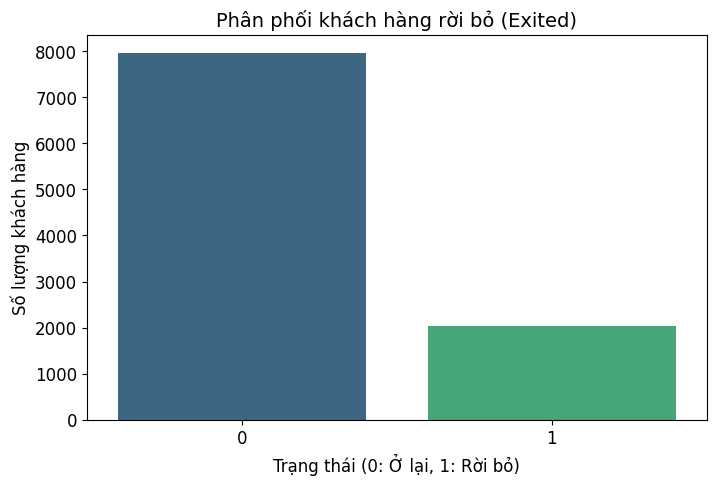


📊 Tỷ lệ khách hàng rời bỏ:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [7]:
# Thông tin tổng quan
print("📋 Thông tin dữ liệu:")
df.info()

# Kiểm tra giá trị null
print("\n❓ Số lượng giá trị null trong từng cột:")
print(df.isnull().sum())

# Phân phối biến mục tiêu
plt.figure(figsize=(8, 5))
sns.countplot(x='Exited', data=df, palette='viridis')
plt.title('Phân phối khách hàng rời bỏ (Exited)', fontsize=14)
plt.xlabel('Trạng thái (0: Ở lại, 1: Rời bỏ)')
plt.ylabel('Số lượng khách hàng')
plt.show()

print("\n📊 Tỷ lệ khách hàng rời bỏ:")
print(df['Exited'].value_counts(normalize=True) * 100)

In [8]:
# 1. Xóa các cột không cần thiết
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print("✅ Đã xóa các cột: RowNumber, CustomerId, Surname")

# 2. Mã hóa biến Gender (Label Encoding)
le_gender = LabelEncoder()
df_clean['Gender'] = le_gender.fit_transform(df_clean['Gender'])
print("✅ Đã mã hóa Gender: 0=Female, 1=Male")

# 3. Mã hóa biến Geography (One-Hot Encoding)
df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=True)
print("✅ Đã mã hóa Geography thành các cột: Geography_Germany, Geography_Spain")

print("\n📊 Dữ liệu sau tiền xử lý:")
df_clean.head()

✅ Đã xóa các cột: RowNumber, CustomerId, Surname
✅ Đã mã hóa Gender: 0=Female, 1=Male
✅ Đã mã hóa Geography thành các cột: Geography_Germany, Geography_Spain

📊 Dữ liệu sau tiền xử lý:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [9]:
# Tách đặc trưng và biến mục tiêu
X = df_clean.drop('Exited', axis=1).values
y = df_clean['Exited'].values

# Chia dữ liệu: Train (70%), Validation (15%), Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"✅ Kích thước tập Train: {X_train.shape}")
print(f"✅ Kích thước tập Validation: {X_val.shape}")
print(f"✅ Kích thước tập Test: {X_test.shape}")

# Chuẩn hóa dữ liệu (StandardScaler) - áp dụng cho các cột số
# Lưu ý: Vì X đã là numpy array nên chúng ta chuẩn hóa toàn bộ
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("✅ Đã chuẩn hóa dữ liệu")

# Chuyển sang PyTorch Tensor
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).reshape(-1, 1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).reshape(-1, 1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).reshape(-1, 1)

# Tạo DataLoader
batch_size = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("✅ Đã tạo DataLoader thành công!")

✅ Kích thước tập Train: (7000, 11)
✅ Kích thước tập Validation: (1500, 11)
✅ Kích thước tập Test: (1500, 11)
✅ Đã chuẩn hóa dữ liệu
✅ Đã tạo DataLoader thành công!


In [10]:
# Định nghĩa mô hình ANN
class ChurnModel(nn.Module):
    def __init__(self, input_size):
        super(ChurnModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.sigmoid(self.fc4(x))
        return x

# Khởi tạo mô hình
input_size = X_train.shape[1]
model = ChurnModel(input_size).to(device)

# Định nghĩa loss function và optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
print(f"\n✅ Mô hình có {sum(p.numel() for p in model.parameters())} tham số")

ChurnModel(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

✅ Mô hình có 12289 tham số


✅ Khởi tạo mô hình với Learning Rate = 0.01
ChurnModel(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

🚀 BẮT ĐẦU HUẤN LUYỆN
Epoch  10: LR=0.010000 | Train Loss=0.3684 | Val Loss=0.3347 | Train Acc=84.83% | Val Acc=86.27%
Epoch  20: LR=0.005000 | Train Loss=0.3576 | Val Loss=0.3330 | Train Acc=85.44% | Val Acc=85.60%
Epoch  30: LR=0.005000 | Train Loss=0.3473 | Val Loss=0.3299 | Train Acc=85.61% | Val Acc=86.67%
Epoch  40: LR=0.002500 | Train Loss=0.3372 | Val Loss=0.3188 | Train Acc=86.21% | Val Acc=87.13%
Epoch  50: LR=0.001250 | Trai

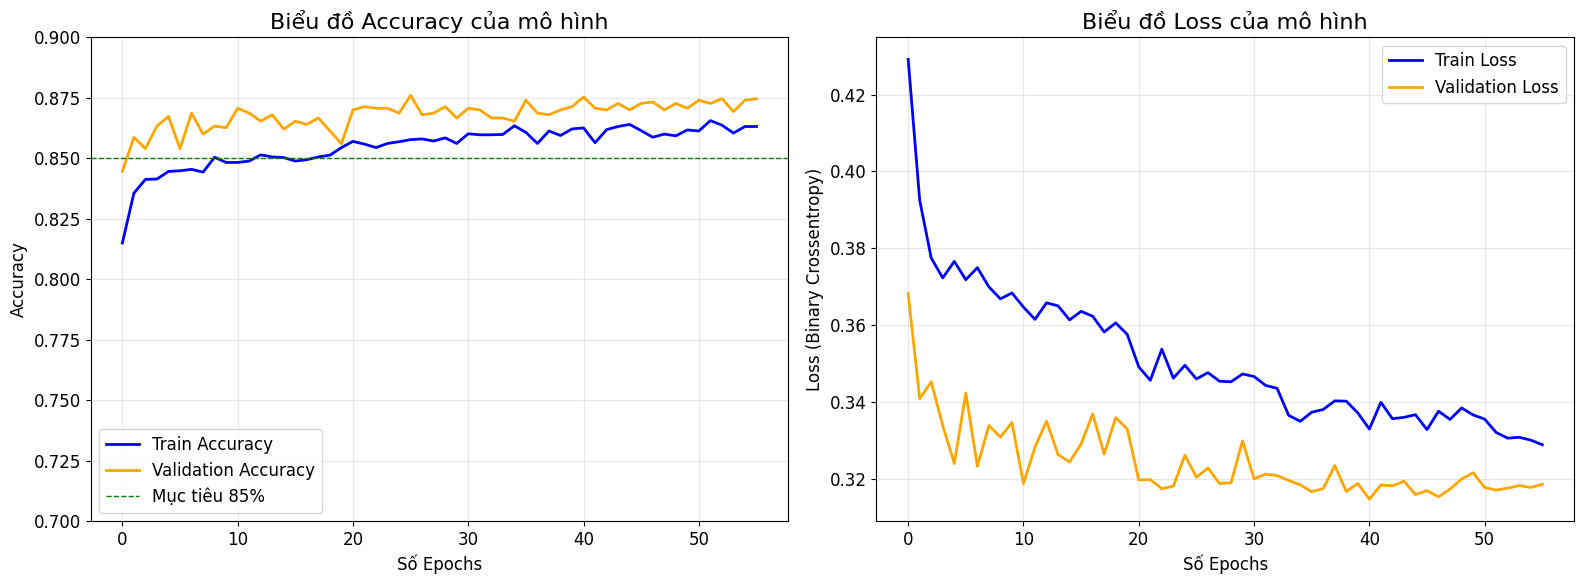


📊 Kết quả cuối cùng:
Train Accuracy: 86.31%
Validation Accuracy: 87.47%
Train Loss: 0.3289
Validation Loss: 0.3186

🔍 Nhận xét:
✅ Mô hình hoạt động tốt, accuracy đạt trên 85%


In [11]:
# Import thêm thư viện
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.init as init

# Định nghĩa mô hình với khởi tạo trọng số tốt hơn
class ChurnModel(nn.Module):
    def __init__(self, input_size):
        super(ChurnModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        # Khởi tạo trọng số Xavier để học tốt hơn
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    init.zeros_(m.bias)

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.sigmoid(self.fc4(x))
        return x

# Khởi tạo mô hình
input_size = X_train.shape[1]
model = ChurnModel(input_size).to(device)

# ✅ TĂNG LEARNING RATE lên 0.01 để học nhanh hơn
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Scheduler giảm LR khi loss plateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8)

# Loss function
criterion = nn.BCELoss()

print("✅ Khởi tạo mô hình với Learning Rate = 0.01")
print("="*60)
print(model)

# ===== BẮT ĐẦU HUẤN LUYỆN =====
# Lưu lịch sử huấn luyện
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Early stopping
best_val_loss = float('inf')
patience = 15
counter = 0
epochs = 150

print("\n🚀 BẮT ĐẦU HUẤN LUYỆN")
print("="*60)

for epoch in range(epochs):
    # ===== TRAINING =====
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Forward pass
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping để tránh exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item()

        # Tính accuracy
        predicted = (y_pred > 0.5).float()
        train_correct += (predicted == y_batch).sum().item()
        train_total += y_batch.size(0)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            val_loss += loss.item()

            predicted = (y_pred > 0.5).float()
            val_correct += (predicted == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Cập nhật learning rate nếu loss không giảm
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        counter += 1
        if counter >= patience:
            print(f"🛑 Early stopping tại epoch {epoch+1}")
            break

    # In kết quả mỗi 10 epochs
    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d}: LR={current_lr:.6f} | Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | Train Acc={train_acc:.2%} | Val Acc={val_acc:.2%}")

print("="*60)
print("✅ Đã huấn luyện mô hình xong!")

# Load model tốt nhất
model.load_state_dict(torch.load('best_model.pth'))
print(f"📊 Best Validation Loss: {best_val_loss:.4f}")

# ===== HIỂN THỊ BIỂU ĐỒ =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ Accuracy
axes[0].plot(train_accuracies, label='Train Accuracy', linewidth=2, color='blue')
axes[0].plot(val_accuracies, label='Validation Accuracy', linewidth=2, color='orange')
axes[0].axhline(y=0.85, color='green', linestyle='--', linewidth=1, label='Mục tiêu 85%')
axes[0].set_title('Biểu đồ Accuracy của mô hình', fontsize=16)
axes[0].set_xlabel('Số Epochs', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.7, 0.9])

# Biểu đồ Loss
axes[1].plot(train_losses, label='Train Loss', linewidth=2, color='blue')
axes[1].plot(val_losses, label='Validation Loss', linewidth=2, color='orange')
axes[1].set_title('Biểu đồ Loss của mô hình', fontsize=16)
axes[1].set_xlabel('Số Epochs', fontsize=12)
axes[1].set_ylabel('Loss (Binary Crossentropy)', fontsize=12)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# In thông số cuối cùng
print("\n📊 Kết quả cuối cùng:")
print(f"Train Accuracy: {train_accuracies[-1]:.2%}")
print(f"Validation Accuracy: {val_accuracies[-1]:.2%}")
print(f"Train Loss: {train_losses[-1]:.4f}")
print(f"Validation Loss: {val_losses[-1]:.4f}")

print("\n🔍 Nhận xét:")
if train_accuracies[-1] > 0.85 and val_accuracies[-1] > 0.85:
    print("✅ Mô hình hoạt động tốt, accuracy đạt trên 85%")
elif val_losses[-1] > train_losses[-1] * 1.2:
    print("⚠️ Có dấu hiệu Overfitting (Val Loss cao hơn Train Loss nhiều)")
else:
    print("ℹ️ Mô hình đang học ổn định")

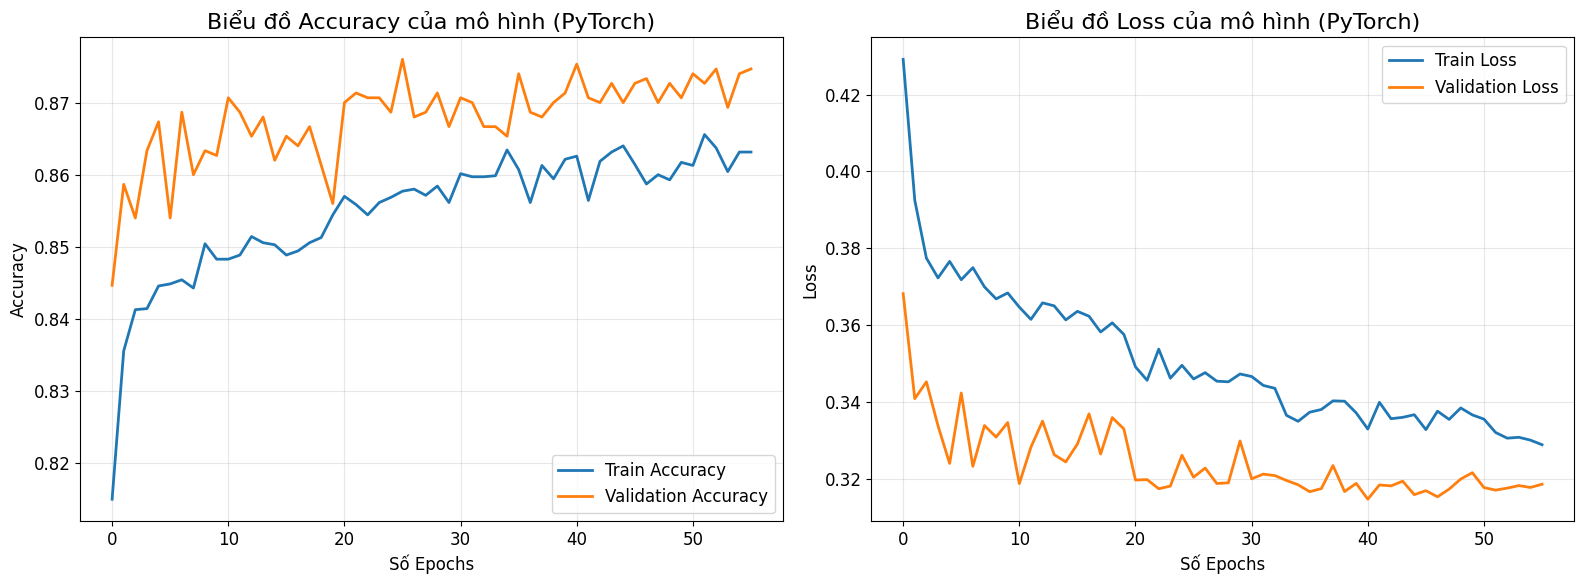

In [12]:
# Vẽ biểu đồ Accuracy và Loss
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ Accuracy
axes[0].plot(train_accuracies, label='Train Accuracy', linewidth=2)
axes[0].plot(val_accuracies, label='Validation Accuracy', linewidth=2)
axes[0].set_title('Biểu đồ Accuracy của mô hình (PyTorch)', fontsize=16)
axes[0].set_xlabel('Số Epochs', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Biểu đồ Loss
axes[1].plot(train_losses, label='Train Loss', linewidth=2)
axes[1].plot(val_losses, label='Validation Loss', linewidth=2)
axes[1].set_title('Biểu đồ Loss của mô hình (PyTorch)', fontsize=16)
axes[1].set_xlabel('Số Epochs', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

🎯 Accuracy trên tập Test: 0.8720
📉 Loss trên tập Test: 0.3254


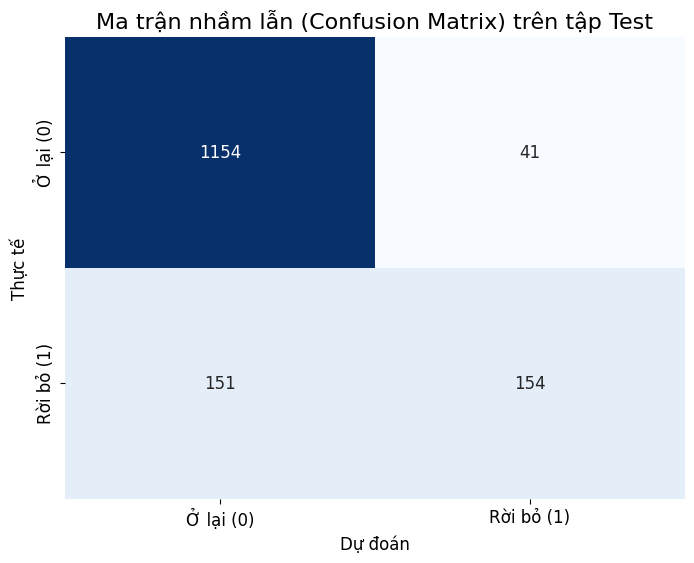


📋 Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

   Ở lại (0)       0.88      0.97      0.92      1195
  Rời bỏ (1)       0.79      0.50      0.62       305

    accuracy                           0.87      1500
   macro avg       0.84      0.74      0.77      1500
weighted avg       0.87      0.87      0.86      1500



In [13]:
# Đánh giá trên tập Test
model.eval() # Chuyển mô hình sang chế độ đánh giá
test_loss = 0
test_correct = 0
test_total = 0
all_y_true = []
all_y_pred = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        y_pred_prob = model(X_batch)
        loss = criterion(y_pred_prob, y_batch)

        test_loss += loss.item()

        predicted = (y_pred_prob > 0.5).float()
        test_correct += (predicted == y_batch).sum().item()
        test_total += y_batch.size(0)

        all_y_true.extend(y_batch.cpu().numpy())
        all_y_pred.extend(predicted.cpu().numpy())

test_loss /= len(test_loader)
test_accuracy = test_correct / test_total

print(f"🎯 Accuracy trên tập Test: {test_accuracy:.4f}")
print(f"📉 Loss trên tập Test: {test_loss:.4f}")

# Dự đoán trên tập Test (sử dụng all_y_true và all_y_pred đã thu thập)
y_test_np = np.array(all_y_true)
y_pred_np = np.array(all_y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test_np, y_pred_np)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Ở lại (0)', 'Rời bỏ (1)'],
            yticklabels=['Ở lại (0)', 'Rời bỏ (1)'])
plt.title('Ma trận nhầm lẫn (Confusion Matrix) trên tập Test', fontsize=16)
plt.xlabel('Dự đoán', fontsize=12)
plt.ylabel('Thực tế', fontsize=12)
plt.show()

# Báo cáo phân loại chi tiết
print("\n📋 Báo cáo phân loại chi tiết:")
print(classification_report(y_test_np, y_pred_np, target_names=['Ở lại (0)', 'Rời bỏ (1)']))

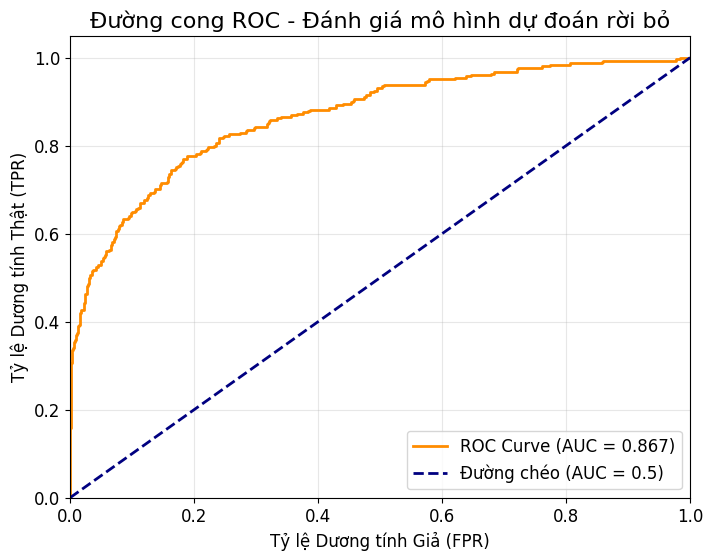

In [14]:
# ROC Curve

# Collect probabilities for the entire test set
model.eval()
all_y_pred_prob = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        y_pred_prob_batch = model(X_batch)
        all_y_pred_prob.extend(y_pred_prob_batch.cpu().numpy())

y_pred_prob_full = np.array(all_y_pred_prob)

fpr, tpr, thresholds = roc_curve(y_test_np, y_pred_prob_full)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Đường chéo (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính Giả (FPR)', fontsize=12)
plt.ylabel('Tỷ lệ Dương tính Thật (TPR)', fontsize=12)
plt.title('Đường cong ROC - Đánh giá mô hình dự đoán rời bỏ', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


🚀 BẮT ĐẦU HUẤN LUYỆN RANDOM FOREST...
✅ Đã huấn luyện xong Random Forest!

📊 ĐÁNH GIÁ RANDOM FOREST TRÊN TẬP TEST:
✅ Accuracy của Random Forest: 0.8693

📋 Báo cáo phân loại Random Forest:
              precision    recall  f1-score   support

   Ở lại (0)       0.87      0.98      0.92      1195
  Rời bỏ (1)       0.83      0.45      0.58       305

    accuracy                           0.87      1500
   macro avg       0.85      0.71      0.75      1500
weighted avg       0.86      0.87      0.85      1500


📊 Ma trận nhầm lẫn Random Forest:
[[1166   29]
 [ 167  138]]

📈 VẼ ROC CURVE SO SÁNH DNN VÀ RANDOM FOREST


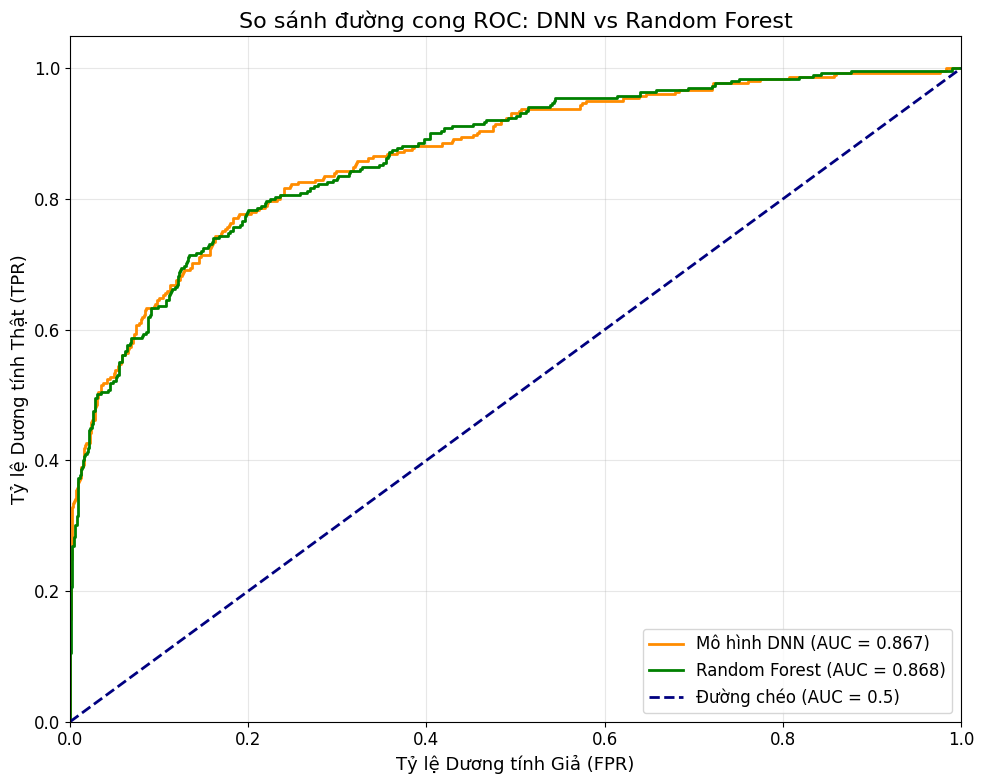


📊 KẾT QUẢ SO SÁNH AUC
✅ AUC của mô hình DNN: 0.8674
✅ AUC của mô hình Random Forest: 0.8682

🔍 Kết luận: Random Forest (AUC = 0.8682) có khả năng phân biệt TỐT HƠN DNN (AUC = 0.8674)


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ============================================================
# HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST
# ============================================================
print("\n🚀 BẮT ĐẦU HUẤN LUYỆN RANDOM FOREST...")

rf_model = RandomForestClassifier(
    n_estimators=100,        # Số cây trong rừng
    max_depth=10,            # Độ sâu tối đa của cây
    min_samples_split=5,     # Số mẫu tối thiểu để split một node
    min_samples_leaf=2,      # Số mẫu tối thiểu ở một leaf
    random_state=42,
    n_jobs=-1                # Sử dụng tất cả CPU
)

# Huấn luyện trên tập train (X_train và y_train đã có từ cell hbL8GGjSX8VR)
rf_model.fit(X_train, y_train)

print("✅ Đã huấn luyện xong Random Forest!")

print("\n📊 ĐÁNH GIÁ RANDOM FOREST TRÊN TẬP TEST:")

# Dự đoán trên tập test (X_test và y_test đã có từ cell hbL8GGjSX8VR)
y_test_pred_rf = rf_model.predict(X_test)
y_test_prob_rf = rf_model.predict_proba(X_test)[:, 1] # Xác suất cho lớp 1 (rời bỏ)

rf_accuracy = accuracy_score(y_test, y_test_pred_rf)
print(f"✅ Accuracy của Random Forest: {rf_accuracy:.4f}")

# Báo cáo phân loại chi tiết
print("\n📋 Báo cáo phân loại Random Forest:")
print(classification_report(y_test, y_test_pred_rf, target_names=['Ở lại (0)', 'Rời bỏ (1)']))

# Ma trận nhầm lẫn
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
print("\n📊 Ma trận nhầm lẫn Random Forest:")
print(cm_rf)

# ============================================================
# SO SÁNH ROC CURVE: DNN vs RANDOM FOREST
# ============================================================
print("\n" + "="*60)
print("📈 VẼ ROC CURVE SO SÁNH DNN VÀ RANDOM FOREST")
print("="*60)

# --- 1. Lấy xác suất dự đoán từ Random Forest (đã tính ở trên) ---

# --- 2. Tính ROC cho Random Forest ---
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# --- 3. ROC cho DNN (đã có từ code cũ, y_test_np, y_pred_prob_full từ các cell trước) ---
fpr_dnn, tpr_dnn, _ = roc_curve(y_test_np, y_pred_prob_full)
auc_dnn = auc(fpr_dnn, tpr_dnn)

# --- 4. Vẽ biểu đồ so sánh ---
plt.figure(figsize=(10, 8))

# Đường ROC của DNN (màu cam)
plt.plot(fpr_dnn, tpr_dnn, color='darkorange', lw=2,
         label=f'Mô hình DNN (AUC = {auc_dnn:.3f})')

# Đường ROC của Random Forest (màu xanh lá)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2,
         label=f'Random Forest (AUC = {auc_rf:.3f})')

# Đường chéo (mô hình ngẫu nhiên)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Đường chéo (AUC = 0.5)')

# Cài đặt biểu đồ
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính Giả (FPR)', fontsize=13)
plt.ylabel('Tỷ lệ Dương tính Thật (TPR)', fontsize=13)
plt.title('So sánh đường cong ROC: DNN vs Random Forest', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 5. In kết quả so sánh ---
print("\n" + "="*60)
print("📊 KẾT QUẢ SO SÁNH AUC")
print("="*60)
print(f"✅ AUC của mô hình DNN: {auc_dnn:.4f}")
print(f"✅ AUC của mô hình Random Forest: {auc_rf:.4f}")

if auc_dnn > auc_rf:
    print(f"\n🔍 Kết luận: Mô hình DNN (AUC = {auc_dnn:.4f}) có khả năng phân biệt TỐT HƠN Random Forest (AUC = {auc_rf:.4f})")
else:
    print(f"\n🔍 Kết luận: Random Forest (AUC = {auc_rf:.4f}) có khả năng phân biệt TỐT HƠN DNN (AUC = {auc_dnn:.4f})")

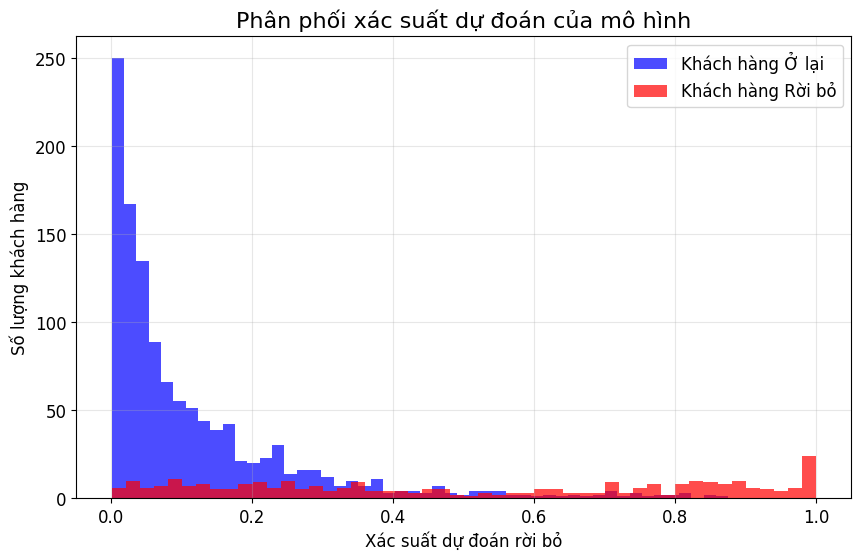

In [ ]:
# Phân phối xác suất dự đoán
plt.figure(figsize=(10, 6))
plt.hist(y_pred_prob_full[y_test_np == 0], bins=50, alpha=0.7, label='Khách hàng Ở lại', color='blue')
plt.hist(y_pred_prob_full[y_test_np == 1], bins=50, alpha=0.7, label='Khách hàng Rời bỏ', color='red')
plt.xlabel('Xác suất dự đoán rời bỏ', fontsize=12)
plt.ylabel('Số lượng khách hàng', fontsize=12)
plt.title('Phân phối xác suất dự đoán của mô hình', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Tổng kết kết quả
print("="*50)
print("📊 KẾT QUẢ MÔ HÌNH DỰ ĐOÁN RỜI BỎ")
print("="*50)
print(f"✅ Độ chính xác (Accuracy) trên tập Test: {test_accuracy:.2%}")
print(f"✅ AUC Score: {roc_auc:.3f}")
print("\n🔍 Nhận xét:")
print("- Nếu Accuracy > 80%: Mô hình hoạt động tốt")
print("- Nếu AUC > 0.8: Mô hình có khả năng phân biệt tốt")
print("- So sánh Precision/Recall của 2 lớp để đánh giá mô hình")

📊 KẾT QUẢ MÔ HÌNH DỰ ĐOÁN RỜI BỎ
✅ Độ chính xác (Accuracy) trên tập Test: 86.60%
✅ AUC Score: 0.865

🔍 Nhận xét:
- Nếu Accuracy > 80%: Mô hình hoạt động tốt
- Nếu AUC > 0.8: Mô hình có khả năng phân biệt tốt
- So sánh Precision/Recall của 2 lớp để đánh giá mô hình
